# 02 - Regularisation, Sparsity and Proximal Algorithms

**Advanced Machine Learning** | Haydar Kilic

Ridge and lasso solve the same least-squares problem under two different
constraints,

$$\hat w^{\text{ridge}} = \arg\min_w \|y - Xw\|_2^2 + \alpha\|w\|_2^2,
\qquad
\hat w^{\text{lasso}} = \arg\min_w \tfrac{1}{2n}\|y - Xw\|_2^2 + \alpha\|w\|_1 ,$$

and the difference in geometry -- a sphere versus a cross-polytope -- is what
makes one shrink and the other *select*. The price is that $\|w\|_1$ is not
differentiable at zero, so we need optimality conditions and algorithms built
on subgradients.

In [1]:
# =========================================================================
# Toolkit for this lecture: the implementations used below, inlined so the
# notebook runs on its own (NumPy / SciPy / Matplotlib only).
# Read them alongside the derivations -- each block mirrors one formula.
# =========================================================================
from __future__ import annotations

import numpy as np

# --- datasets ------------------------------------------------------

def _rng(random_state: int | np.random.Generator | None) -> np.random.Generator:
    if isinstance(random_state, np.random.Generator):
        return random_state
    return np.random.default_rng(random_state)

def make_friedman1(n_samples=200, n_features=10, noise=1.0, random_state=None):
    r"""Friedman #1 benchmark.

    .. math::
        y = 10\sin(\pi x_0 x_1) + 20 (x_2 - 0.5)^2 + 10 x_3 + 5 x_4 + \varepsilon

    Only the first five features are informative -- the rest are distractors,
    which makes it a good stress test for sparse models and tree ensembles.
    """
    if n_features < 5:
        raise ValueError("Friedman #1 needs at least 5 features.")
    rng = _rng(random_state)
    X = rng.uniform(size=(n_samples, n_features))
    y = (
        10.0 * np.sin(np.pi * X[:, 0] * X[:, 1])
        + 20.0 * (X[:, 2] - 0.5) ** 2
        + 10.0 * X[:, 3]
        + 5.0 * X[:, 4]
    )
    y = y + noise * rng.standard_normal(n_samples)
    return X, y

def train_test_split(*arrays, test_size=0.25, random_state=None, stratify=None):
    """Shuffle-split arrays, optionally stratified by ``stratify`` labels."""
    if not arrays:
        raise ValueError("At least one array is required.")
    n = len(arrays[0])
    for arr in arrays:
        if len(arr) != n:
            raise ValueError("All arrays must share the same first dimension.")
    rng = _rng(random_state)

    if stratify is None:
        idx = rng.permutation(n)
        n_test = int(round(test_size * n))
        test_idx, train_idx = idx[:n_test], idx[n_test:]
    else:
        stratify = np.asarray(stratify)
        train_parts, test_parts = [], []
        for value in np.unique(stratify):
            group = np.flatnonzero(stratify == value)
            group = group[rng.permutation(len(group))]
            n_test = int(round(test_size * len(group)))
            test_parts.append(group[:n_test])
            train_parts.append(group[n_test:])
        train_idx = np.concatenate(train_parts)
        test_idx = np.concatenate(test_parts)
        train_idx = train_idx[rng.permutation(len(train_idx))]
        test_idx = test_idx[rng.permutation(len(test_idx))]

    out = []
    for arr in arrays:
        arr = np.asarray(arr)
        out.extend([arr[train_idx], arr[test_idx]])
    return tuple(out)

# --- metrics -------------------------------------------------------

_EPS = 1e-12

def mse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.mean((y_true - y_pred) ** 2))

def r2_score(y_true, y_pred):
    r"""Coefficient of determination :math:`1 - SS_{res}/SS_{tot}`."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1.0 - ss_res / (ss_tot + _EPS))

# --- preprocessing -------------------------------------------------

class StandardScaler:
    """Zero mean / unit variance scaling."""

    def __init__(self, with_mean=True, with_std=True):
        self.with_mean = with_mean
        self.with_std = with_std

    def fit(self, X, y=None):
        X = np.asarray(X, float)
        self.mean_ = X.mean(axis=0) if self.with_mean else np.zeros(X.shape[1])
        scale = X.std(axis=0) if self.with_std else np.ones(X.shape[1])
        self.scale_ = np.where(scale < 1e-12, 1.0, scale)
        return self

    def transform(self, X):
        return (np.asarray(X, float) - self.mean_) / self.scale_

    def fit_transform(self, X, y=None):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        return np.asarray(X, float) * self.scale_ + self.mean_

# --- linear --------------------------------------------------------

class _CenteredLinearModel:
    """Shared centring logic: fit on centred data, recover the intercept after."""

    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = 0.0

    def _center(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        if self.fit_intercept:
            self._x_mean = X.mean(axis=0)
            self._y_mean = y.mean()
            return X - self._x_mean, y - self._y_mean
        self._x_mean = np.zeros(X.shape[1])
        self._y_mean = 0.0
        return X, y

    def _set_intercept(self):
        self.intercept_ = float(self._y_mean - self._x_mean @ self.coef_)

    def predict(self, X):
        return np.asarray(X, float) @ self.coef_ + self.intercept_

def soft_threshold(z, gamma):
    r"""Proximal operator of the L1 norm, :math:`S_\gamma(z)`."""
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)

class RidgeRegression(_CenteredLinearModel):
    r"""Ridge regression.

    Minimises :math:`\|y - Xw\|_2^2 + \alpha \|w\|_2^2`.  The SVD
    :math:`X = U D V^\top` gives the shrinkage form

    .. math:: \hat w = V \operatorname{diag}\!\left(\frac{d_j}{d_j^2+\alpha}\right) U^\top y,

    which also exposes the effective degrees of freedom
    :math:`\mathrm{df}(\alpha) = \sum_j d_j^2 / (d_j^2 + \alpha)`.
    """

    def __init__(self, alpha=1.0, fit_intercept=True):
        super().__init__(fit_intercept)
        self.alpha = float(alpha)

    def fit(self, X, y):
        Xc, yc = self._center(X, y)
        U, d, Vt = np.linalg.svd(Xc, full_matrices=False)
        shrink = d / (d**2 + self.alpha)
        self.coef_ = Vt.T @ (shrink * (U.T @ yc))
        self.singular_values_ = d
        self.effective_dof_ = float(np.sum(d**2 / (d**2 + self.alpha)))
        self._set_intercept()
        return self

    def path(self, X, y, alphas):
        """Coefficient path over a grid of ``alphas`` (one row per alpha)."""
        Xc, yc = self._center(X, y)
        U, d, Vt = np.linalg.svd(Xc, full_matrices=False)
        Uty = U.T @ yc
        return np.stack([Vt.T @ ((d / (d**2 + a)) * Uty) for a in alphas])

class LassoRegression(_CenteredLinearModel):
    r"""Elastic net / lasso.

    Objective (``l1_ratio=1`` is the pure lasso):

    .. math::
        \frac{1}{2n}\|y - Xw\|_2^2
        + \alpha\rho\|w\|_1 + \frac{\alpha(1-\rho)}{2}\|w\|_2^2 .

    ``solver="cd"`` runs cyclic coordinate descent, ``"ista"`` the proximal
    gradient method and ``"fista"`` its accelerated variant, so the three can be
    compared on the same objective in the notebooks.
    """

    def __init__(self, alpha=0.1, l1_ratio=1.0, solver="cd", max_iter=1000, tol=1e-6,
                 fit_intercept=True):
        super().__init__(fit_intercept)
        self.alpha = float(alpha)
        self.l1_ratio = float(l1_ratio)
        self.solver = solver
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.loss_history_ = []

    # -- objective ---------------------------------------------------------
    def _objective(self, X, y, w):
        n = len(y)
        resid = y - X @ w
        l1 = self.alpha * self.l1_ratio * np.sum(np.abs(w))
        l2 = 0.5 * self.alpha * (1 - self.l1_ratio) * np.sum(w**2)
        return float(resid @ resid / (2 * n) + l1 + l2)

    # -- solvers -----------------------------------------------------------
    def _fit_cd(self, X, y):
        n, p = X.shape
        w = np.zeros(p)
        col_sq = (X**2).sum(axis=0) / n
        resid = y.copy()
        l1 = self.alpha * self.l1_ratio
        l2 = self.alpha * (1 - self.l1_ratio)
        for _ in range(self.max_iter):
            max_delta = 0.0
            for j in range(p):
                if col_sq[j] == 0.0:
                    continue
                rho = X[:, j] @ (resid + X[:, j] * w[j]) / n
                new_wj = soft_threshold(rho, l1) / (col_sq[j] + l2)
                delta = new_wj - w[j]
                if delta != 0.0:
                    resid -= X[:, j] * delta
                    w[j] = new_wj
                    max_delta = max(max_delta, abs(delta))
            self.loss_history_.append(self._objective(X, y, w))
            if max_delta < self.tol:
                break
        return w

    def _fit_prox_gradient(self, X, y, accelerate):
        n, p = X.shape
        step = 1.0 / (np.linalg.norm(X, 2) ** 2 / n + self.alpha * (1 - self.l1_ratio))
        w = np.zeros(p)
        z, t = w.copy(), 1.0
        l1 = self.alpha * self.l1_ratio
        l2 = self.alpha * (1 - self.l1_ratio)
        for _ in range(self.max_iter):
            grad = X.T @ (X @ z - y) / n + l2 * z
            w_new = soft_threshold(z - step * grad, step * l1)
            if accelerate:
                t_new = 0.5 * (1 + np.sqrt(1 + 4 * t**2))
                z = w_new + ((t - 1) / t_new) * (w_new - w)
                t = t_new
            else:
                z = w_new
            delta = np.max(np.abs(w_new - w))
            w = w_new
            self.loss_history_.append(self._objective(X, y, w))
            if delta < self.tol:
                break
        return w

    def fit(self, X, y):
        Xc, yc = self._center(X, y)
        self.loss_history_ = []
        if self.solver == "cd":
            self.coef_ = self._fit_cd(Xc, yc)
        elif self.solver in ("ista", "fista"):
            self.coef_ = self._fit_prox_gradient(Xc, yc, accelerate=self.solver == "fista")
        else:
            raise ValueError(f"Unknown solver: {self.solver!r}")
        self.n_nonzero_ = int(np.sum(np.abs(self.coef_) > 1e-10))
        self._set_intercept()
        return self

    def path(self, X, y, alphas):
        """Warm-started coefficient path (alphas are used in the given order)."""
        coefs = []
        original = self.alpha
        try:
            for a in alphas:
                self.alpha = a
                self.fit(X, y)
                coefs.append(self.coef_.copy())
        finally:
            self.alpha = original
        return np.stack(coefs)

# --- viz -----------------------------------------------------------

PALETTE = ["#1f4e79", "#c0392b", "#27865f", "#8e44ad", "#d68910", "#2c3e50"]

def set_style():
    """Apply a clean, print-friendly default style."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams.update({
        "figure.figsize": (7.0, 4.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.frameon": False,
        "font.size": 10,
        "axes.prop_cycle": mpl.cycler(color=PALETTE),
    })
    return plt

In [2]:
plt = set_style()

rng = np.random.default_rng(0)
n, p = 120, 30
X = rng.standard_normal((n, p))
w_true = np.zeros(p)
w_true[[0, 4, 9, 17]] = [3.0, -2.0, 1.5, -1.0]     # only 4 of 30 features matter
y = X @ w_true + 0.5 * rng.standard_normal(n)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(f"{p} features, {int((w_true != 0).sum())} of them relevant")

30 features, 4 of them relevant


## 1. Two shrinkage paths

In the SVD basis $X = UDV^\top$ ridge shrinks each direction by
$d_j^2/(d_j^2+\alpha)$: low-variance directions are damped hardest, but nothing
ever reaches exactly zero. The lasso path, by contrast, sets coefficients to
zero one after another.

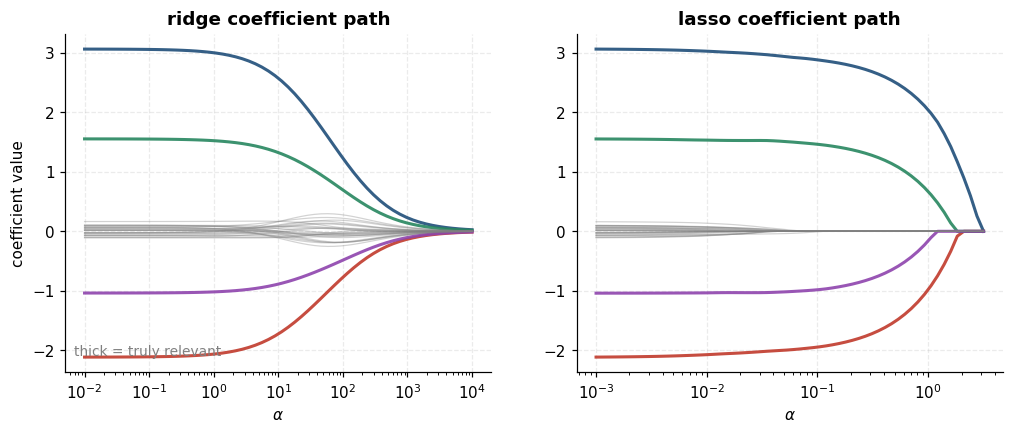

non-zeros along the lasso path: [0, 4, 4, 19, 30]


In [3]:
alphas_ridge = np.logspace(-2, 4, 60)
alphas_lasso = np.logspace(-3, 0.5, 60)[::-1]        # warm start from large alpha
ridge_path = RidgeRegression().path(X_train, y_train, alphas_ridge)
lasso_path = LassoRegression(max_iter=3000).path(X_train, y_train, alphas_lasso)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for j in range(p):
    style = dict(lw=2.0, alpha=0.9) if w_true[j] != 0 else dict(lw=0.8, alpha=0.35,
                                                                color="grey")
    axes[0].plot(alphas_ridge, ridge_path[:, j], **style)
    axes[1].plot(alphas_lasso, lasso_path[:, j], **style)
for ax, name in zip(axes, ["ridge", "lasso"]):
    ax.set_xscale("log")
    ax.set_xlabel(r"$\alpha$")
    ax.set_title(f"{name} coefficient path")
axes[0].set_ylabel("coefficient value")
axes[0].text(0.02, 0.05, "thick = truly relevant", transform=axes[0].transAxes,
             fontsize=9, color="grey")
plt.show()

print("non-zeros along the lasso path:",
      [int(np.sum(np.abs(c) > 1e-6)) for c in lasso_path[::12]])

## 2. Why the lasso produces exact zeros

At a minimum of $F(w) = \tfrac{1}{2n}\|y-Xw\|^2 + \alpha\|w\|_1$ the zero vector
must lie in the subdifferential, which coordinate-wise reads

$$\frac{1}{n} x_j^\top (Xw - y) + \alpha s_j = 0, \qquad
s_j \in \begin{cases}\{\operatorname{sign}(w_j)\} & w_j \neq 0\\ [-1, 1] & w_j = 0.\end{cases}$$

So $w_j = 0$ is optimal whenever the correlation $|x_j^\top r|/n \le \alpha$:
a whole *interval* of gradients is compatible with staying at zero, which is
exactly what a differentiable penalty like ridge cannot offer. Solving one
coordinate at a time gives the soft-thresholding update

$$w_j \leftarrow \frac{S_{\alpha}(\rho_j)}{\frac1n\|x_j\|^2}, \qquad
S_\gamma(z) = \operatorname{sign}(z)\,(|z| - \gamma)_+ .$$

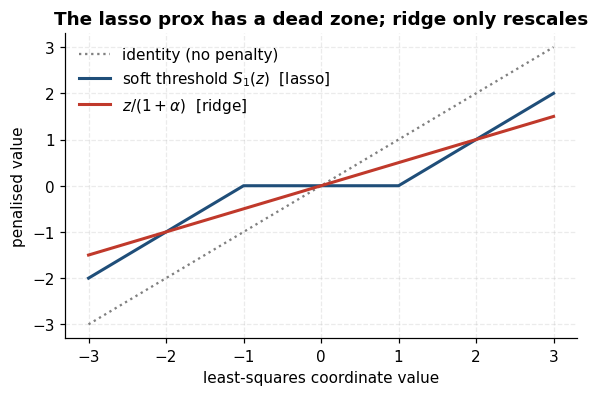

active set: [0, 4, 9, 17, 20]
max |corr| on the active set   : 0.1000  (should equal alpha = 0.1)
max |corr| on the inactive set : 0.0718  (should be <= alpha)


In [4]:
z = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(z, z, ls=":", color="grey", label="identity (no penalty)")
ax.plot(z, soft_threshold(z, 1.0), lw=2, label=r"soft threshold $S_1(z)$  [lasso]")
ax.plot(z, z / (1 + 1.0), lw=2, label=r"$z/(1+\alpha)$  [ridge]")
ax.set_xlabel("least-squares coordinate value")
ax.set_ylabel("penalised value")
ax.set_title("The lasso prox has a dead zone; ridge only rescales")
ax.legend()
plt.show()

# check the KKT conditions on a fitted model
model = LassoRegression(alpha=0.1, max_iter=5000, tol=1e-12).fit(X_train, y_train)
resid = (y_train - y_train.mean()) - (X_train - X_train.mean(0)) @ model.coef_
corr = (X_train - X_train.mean(0)).T @ resid / len(X_train)
active = np.abs(model.coef_) > 1e-8
print(f"active set: {np.flatnonzero(active).tolist()}")
print(f"max |corr| on the active set   : {np.abs(corr[active]).max():.4f}  (should equal alpha = 0.1)")
print(f"max |corr| on the inactive set : {np.abs(corr[~active]).max():.4f}  (should be <= alpha)")

## 3. Three algorithms, one objective

* **Coordinate descent** cycles through coordinates, each solved in closed form.
* **ISTA** is proximal gradient descent: a gradient step followed by the prox,
  $w^{k+1} = S_{\eta\alpha}\bigl(w^k - \eta \nabla g(w^k)\bigr)$, converging at
  rate $O(1/k)$.
* **FISTA** adds Nesterov momentum and reaches $O(1/k^2)$.

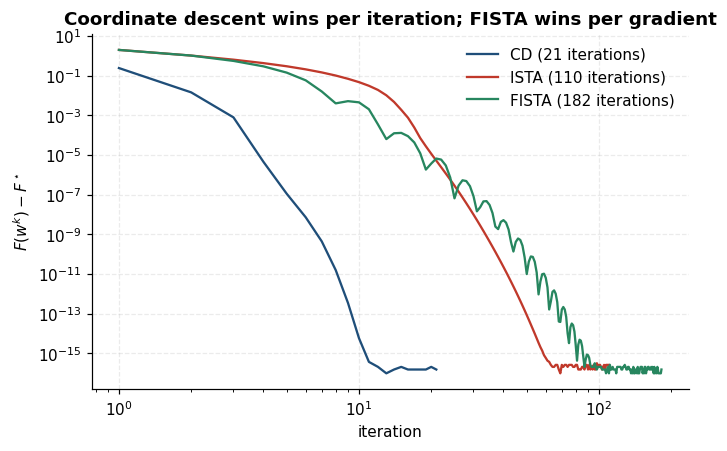

In [5]:
fig, ax = plt.subplots()
for solver, iters in [("cd", 60), ("ista", 800), ("fista", 800)]:
    fitted = LassoRegression(alpha=0.05, solver=solver, max_iter=iters,
                             tol=1e-14).fit(X_train, y_train)
    history = np.asarray(fitted.loss_history_)
    ax.plot(np.arange(1, len(history) + 1), history - history.min() + 1e-16,
            label=f"{solver.upper()} ({len(history)} iterations)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$F(w^k) - F^\star$")
ax.set_title("Coordinate descent wins per iteration; FISTA wins per gradient")
ax.legend()
plt.show()

Coordinate descent needs the fewest passes here because each update is exact,
but every pass touches all $p$ coordinates; FISTA's advantage shows up when a
full pass is expensive or the design matrix is only available as an operator.

## 4. Correlated features: where the lasso is unstable

When two columns are near-duplicates the lasso arbitrarily keeps one and drops
the other, and the choice flips with a small perturbation of the data. The
elastic net,
$\alpha\rho\|w\|_1 + \tfrac{\alpha(1-\rho)}{2}\|w\|_2^2$, keeps correlated
groups together (the "grouping effect").

In [6]:
base = rng.standard_normal((150, 3))
X_corr = np.hstack([base, base + 0.02 * rng.standard_normal((150, 3))])
y_corr = base @ np.array([2.0, -1.5, 1.0]) + 0.3 * rng.standard_normal(150)

for name, ratio in [("lasso      ", 1.0), ("elastic net", 0.4)]:
    coefs = []
    for seed in range(6):                      # resample to see the instability
        idx = np.random.default_rng(seed).choice(150, 120, replace=False)
        fit = LassoRegression(alpha=0.15, l1_ratio=ratio, max_iter=4000)
        fit.fit(X_corr[idx], y_corr[idx])
        coefs.append(fit.coef_)
    coefs = np.array(coefs)
    selection = (np.abs(coefs) > 1e-6).mean(axis=0)
    print(f"{name}: selection frequency per feature = "
          f"{np.round(selection, 2).tolist()}")

lasso      : selection frequency per feature = [1.0, 1.0, 0.33, 0.83, 0.5, 1.0]
elastic net: selection frequency per feature = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


The duplicated pairs (columns 0/3, 1/4, 2/5) are selected erratically by the
lasso and much more consistently by the elastic net.

## 5. Does sparsity pay off predictively?

On Friedman #1 only five of the inputs carry signal, and the rest are pure
distractors -- the regime where an $\ell_1$ penalty should help.

In [7]:
Xf, yf = make_friedman1(300, n_features=40, noise=1.0, random_state=5)
scaler = StandardScaler().fit(Xf)
Xf = scaler.transform(Xf)
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.4, random_state=0)

ridge = RidgeRegression(alpha=10.0).fit(Xf_tr, yf_tr)
lasso = LassoRegression(alpha=0.15, max_iter=5000).fit(Xf_tr, yf_tr)

for name, fit in [("ridge", ridge), ("lasso", lasso)]:
    non_zero = int(np.sum(np.abs(fit.coef_) > 1e-6))
    print(f"{name}: test R^2 = {r2_score(yf_te, fit.predict(Xf_te)):.3f}, "
          f"test MSE = {mse(yf_te, fit.predict(Xf_te)):6.3f}, "
          f"non-zero coefficients = {non_zero:2d}/40")

order = np.argsort(-np.abs(lasso.coef_))[:8]
print("\nlargest lasso coefficients (features 0-4 are the informative ones):")
for j in order:
    print(f"  feature {j:2d}: {lasso.coef_[j]:+.3f}")

ridge: test R^2 = 0.614, test MSE = 10.488, non-zero coefficients = 40/40
lasso: test R^2 = 0.687, test MSE =  8.503, non-zero coefficients = 22/40

largest lasso coefficients (features 0-4 are the informative ones):
  feature  3: +2.639
  feature  1: +1.767
  feature  0: +1.679
  feature  4: +1.487
  feature  9: -0.571
  feature 16: +0.482
  feature 30: -0.347
  feature 28: +0.313


## 6. What to take away

1. Non-differentiability is a feature: the subgradient interval at zero is what
   makes exact sparsity possible.
2. The KKT conditions are a cheap correctness check -- active coordinates sit at
   correlation exactly $\alpha$, inactive ones strictly below.
3. Coordinate descent, ISTA and FISTA optimise the same objective with very
   different iteration costs and rates.
4. Under strong correlation the lasso's selection is unstable; the elastic net
   trades a little sparsity for reproducibility.

**Next:** notebook 03 leaves linear models behind and replaces inner products
with kernels.